# France 2017-2022 extended migration analysis

This notebook extends the original France 2018 pilot to all available FRA facts files from 2017 through 2022.

It adds six hypothesis layers:

1. **Concreteness / abstractness**: score each migration context window and compare WEOG versus non-WEOG mentioned countries.
2. **Institutional cohorts and policy diffusion**: classify migrant cohorts and policy measures, then build a France -> mentioned-country network.
3. **Policy agency mechanisms**: classify whether another country is used as a model, target of pressure, competitor, cooperation partner, or neutral reporting case.
4. **Narrative framing and argument schemes**: classify how migration is imagined and whether the argument is about consequences, practical reasoning, or conceptual definition.
5. **High-concreteness event extraction**: extract concrete evidence snippets for maps and fact-density timelines.
6. **Internal vs external process direction**: distinguish migration into France from migration between other countries.


In [1]:
import sys
from pathlib import Path

# Explanation: Make the src package importable from the notebook directory.
sys.path.insert(0, str(Path.cwd().parent))

import polars as pl
from IPython.display import HTML, Image, Markdown, display

from src import agency, concreteness, diffusion, direction, evidence, events, filters, framing, geo, load, typology, visualize
from src.config import PROCESSED_DIR, SOURCE_COUNTRY, SOURCE_YEARS


## Method notes

**Migration filtering.** We keep rows where `debate_topic == "immig"` and also rows where the previous/current/next sentence window contains migration keywords: `refugee`, `migrant`, `immigrant`, `asylum`, `migration`, or `immigration`.

**Concreteness.** The code supports a Brysbaert-style 1-5 concreteness lexicon if one is supplied. If no lexicon is loaded, the notebook uses a transparent fallback heuristic: named entities are scored as maximally concrete (`5.0`), physical/institutional markers are concrete, and abstract value/principle words are abstract. The output column `concreteness_method` records which method was used.

**Country recognition.** The parquet already contains NER output in `entity_content`; we normalize country-name variants and then map canonical names to ISO3 and WEOG/non-WEOG groups. High-concreteness event extraction also uses `country-named-entity-recognition` to avoid partial matches such as Niger/Nigeria.

**Cohorts, policy measures, agency, frames, and direction.** The current implementation uses auditable keyword rules that produce the same columns a later zero-shot classifier or SRL model would produce. Marker columns and LLM-ready prompts are saved so colleagues can inspect and replace the rules later without changing the output schema.


## Sharper research questions

This notebook treats cross-country references as the core object of the project. The question is not only whether migration is discussed, but **which other countries/entities are invoked, in what kind of language, and as evidence for what kind of policy reasoning**.

**Study 1 - abstraction/concreteness.** When France mentions other countries in migration debates, are non-WEOG countries more often discussed through abstract, generalized, speculative language, while WEOG countries are discussed through more concrete events, institutions, locations, and policy instruments?

**Study 2 - institutional cohorts and diffusion.** When France segments migrants into institutional cohorts such as refugees, asylum seekers, students, economic migrants, or high-skilled workers, which other countries are invoked as models, warnings, comparison cases, or policy references?

The crucial audit step is context reading. Every visual claim below has context CSVs that show the actual parliamentary wording behind the score, cohort label, policy label, country/entity, year, and sentence ID.


In [2]:
# Explanation: Load all available France facts files for 2017-2022 lazily.
lf = load.load_facts_multi_year_lazy(SOURCE_YEARS, country=SOURCE_COUNTRY)
load.inspect_schema(lf)

# Explanation: Quick row-count check by source year before filtering.
lf.group_by("source_year").agg(pl.len().alias("n_rows")).sort("source_year").collect()


=== Schema ===
  entity_word_id: String
  speech_id: String
  paragraph_id: String
  sentence_id: String
  sentence_content_current: String
  sentence_content_previous: String
  sentence_content_next: String
  sentence_sentiment_value: Float32
  sentence_sentiment_ana: String
  total_tokens_in_speech: Int32
  total_tokens_in_session: Int32
  entity_category: String
  entity_content: String
  country: String
  session_date: Date
  debate_topic: String
  speaker_id: String
  speaker_ana: String
  source_year: Int32

Total rows: 1,304,983


source_year,n_rows
i32,u32
2017,132751
2018,321404
2019,287260
2020,241858
2021,268326
2022,53384


In [3]:
# Explanation: Build multi-year migration mentions with country/entity normalization.
mentions = filters.build_migration_mentions(
    lf,
    use_topic=True,
    use_keywords=True,
)
print(f"Retained migration mentions, {SOURCE_YEARS[0]}-{SOURCE_YEARS[-1]}: {mentions.height:,}")

# Explanation: Add all analytical layers used by the hypotheses.
annotated = (
    mentions
    .pipe(typology.apply_typology)
    .pipe(geo.add_country_metadata)
    .pipe(concreteness.add_concreteness_scores)
    .pipe(diffusion.add_diffusion_classifications)
    .pipe(agency.add_policy_agency)
    .pipe(framing.add_narrative_framing)
    .pipe(direction.add_directional_schema)
)

out_path = PROCESSED_DIR / f"{SOURCE_COUNTRY}_{SOURCE_YEARS[0]}_{SOURCE_YEARS[-1]}_migration_mentions_extended.parquet"
annotated.write_parquet(out_path)
print(f"Saved {annotated.height:,} rows to {out_path}")
annotated.head(10)


Retained migration mentions, 2017-2022: 4,256


Saved 4,256 rows to /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/FRA_2017_2022_migration_mentions_extended.parquet


source_year,sentence_id,speech_id,session_date,speaker_id,speaker_ana,entity_content,geo_class,region_group,context_window,sentence_content_current,sentence_sentiment_value,sentence_sentiment_ana,debate_topic,country,ref_type,sentiment_level,sentiment_readable,sentiment_polarity,target_iso3,weog_group,concreteness_score,concreteness_method,concreteness_band,concreteness_token_count,concrete_marker_hits,abstract_marker_hits,migrant_cohort,migrant_cohort_marker,policy_measure,policy_measure_marker,cohort_policy_method,policy_agency_type,policy_agency_marker,policy_agency_llm_prompt,policy_agency_method,narrative_frame,narrative_frame_marker,argument_scheme,conceptual_definition,narrative_method,narrative_polarity,flow_source_candidate,flow_destination_candidate,migration_direction,direction_method
i32,str,str,date,str,str,str,str,str,str,str,f32,str,str,str,str,str,str,str,str,str,f64,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
2017,"""ParlaMint-FR_2017-07-03-C1001.…","""ParlaMint-FR_2017-07-03-C1001.…",2017-07-03,"""PA335758""","""regular""","""European Union""","""european_union""","""european_union""","""We welcome the revival of the …","""We are convinced that only the…",4.642,"""senti:pospos""","""gover""","""FRA""","""situation""","""senti:pospos""","""strong pos""","""positive""",null,"""european_union""",3.286,"""transparent_fallback_heuristic""","""mixed""",42,"""""","""""","""general_migration""","""""","""general_policy""","""""","""keyword_rules""","""learning_emulation_from""","""example""","""Classify the policy diffusion …","""keyword_rules_llm_ready""","""policy_model""","""example""","""practical_reasoning""","""""","""keyword_rules_llm_ready""","""neutral_administrative""","""""","""""","""external_transnational""","""surface_srl_rules"""
2017,"""ParlaMint-FR_2017-07-03-O1001.…","""ParlaMint-FR_2017-07-03-O1001.…",2017-07-03,"""PA335758""","""regular""","""European Union""","""european_union""","""european_union""","""We welcome the revival of the …","""We are convinced that only the…",4.642,"""senti:pospos""","""gover""","""FRA""","""situation""","""senti:pospos""","""strong pos""","""positive""",null,"""european_union""",3.286,"""transparent_fallback_heuristic""","""mixed""",42,"""""","""""","""general_migration""","""""","""general_policy""","""""","""keyword_rules""","""learning_emulation_from""","""example""","""Classify the policy diffusion …","""keyword_rules_llm_ready""","""policy_model""","""example""","""practical_reasoning""","""""","""keyword_rules_llm_ready""","""neutral_administrative""","""""","""""","""external_transnational""","""surface_srl_rules"""
2017,"""ParlaMint-FR_2017-07-04-E1001.…","""ParlaMint-FR_2017-07-04-E1001.…",2017-07-04,"""PA345619""","""regular""","""Mayotte""","""french_overseas""","""french_overseas""","""Courage is also to face the mi…","""The pressure exerted at the bo…",0.179,"""senti:negneg""","""defen""","""FRA""","""situation""","""senti:negneg""","""strong neg""","""negative""",null,"""french_overseas""",3.327,"""transparent_fallback_heuristic""","""concrete_leaning""",30,"""borders, territory""","""""","""general_migration""","""""","""national_security""","""public order""","""keyword_rules""","""learning_emulation_from""","""as in""","""Classify the policy diffusion …","""keyword_rules_llm_ready""","""national_identity""","""nation""","""other""","""""","""keyword_rules_llm_ready""","""neutral_administrative""","""""","""Mayotte""","""external_transnational""","""surface_srl_rules"""
2017,"""ParlaMint-FR_2017-07-04-E1001.…","""ParlaMint-FR_2017-07-04-E1001.…",2017-07-04,"""PA345619""","""regular""","""French Guiana""","""french_overseas""","""french_overseas""","""Courage is also to face the mi…","""The pressure exerted at the bo…",0.179,"""senti:negneg""","""defen""","""FRA""","""situation""","""senti:negneg""","""strong neg""","""negative""",null,"""french_overseas""",3.387,"""transparent_fallback_heuristic""","

In [4]:
# Explanation: Basic yearly coverage after filtering.
yearly_counts = (
    annotated
    .group_by("source_year")
    .agg(pl.len().alias("n_mentions"))
    .sort("source_year")
)
yearly_counts


source_year,n_mentions
i32,u32
2017,468
2018,1728
2019,874
2020,406
2021,544
2022,236


In [5]:
# Explanation: Direct table for the abstraction/concreteness hypothesis.
regional_concreteness = concreteness.regional_concreteness_summary(annotated)
regional_concreteness


weog_group,n_mentions,mean_concreteness,median_concreteness,sd_concreteness
str,u32,f64,f64,f64
"""non_weog""",1070,3.233,3.229,0.057
"""weog""",1014,3.243,3.234,0.072
"""french_overseas""",783,3.25,3.243,0.08
"""unknown""",839,3.259,3.251,0.075
"""european_union""",550,3.296,3.286,0.091


In [6]:
# Explanation: Top mentioned entities across the whole 2017-2022 window.
top_entities = (
    annotated
    .group_by(["entity_content", "geo_class", "region_group", "weog_group", "target_iso3"])
    .agg([
        pl.len().alias("n_mentions"),
        pl.col("concreteness_score").mean().round(3).alias("mean_concreteness"),
    ])
    .sort("n_mentions", descending=True)
    .head(30)
)
top_entities


entity_content,geo_class,region_group,weog_group,target_iso3,n_mentions,mean_concreteness
str,str,str,str,str,u32,f64
"""Mayotte""","""french_overseas""","""french_overseas""","""french_overseas""",null,610,3.262
"""European Union""","""european_union""","""european_union""","""european_union""",null,550,3.296
"""United Kingdom""","""foreign""","""european_country""","""weog""","""GBR""",208,3.26
"""Germany""","""foreign""","""european_country""","""weog""","""DEU""",160,3.229
"""Comoros""","""foreign""","""non_european_country""","""non_weog""","""COM""",152,3.23
…,…,…,…,…,…,…
"""Switzerland""","""foreign""","""european_country""","""weog""","""CHE""",21,3.23
"""Lebanon""","""foreign""","""non_european_country""","""non_weog""","""LBN""",20,3.251
"""Sweden""","""foreign""","""european_country""","""weog""","""SWE""",19,3.229


In [7]:
# Explanation: Build diffusion and agency networks with migrant cohort and policy attributes.
edges = diffusion.build_diffusion_edges(annotated, source_country=SOURCE_COUNTRY)
network_paths = diffusion.save_diffusion_outputs(
    edges,
    processed_dir=PROCESSED_DIR,
    prefix=f"{SOURCE_COUNTRY}_{SOURCE_YEARS[0]}_{SOURCE_YEARS[-1]}",
)

agency_edges = agency.build_agency_edges(annotated, source_country=SOURCE_COUNTRY)
agency_paths = agency.save_agency_outputs(
    agency_edges,
    processed_dir=PROCESSED_DIR,
    prefix=f"{SOURCE_COUNTRY}_{SOURCE_YEARS[0]}_{SOURCE_YEARS[-1]}",
)

event_paths = events.save_event_outputs(
    annotated,
    processed_dir=PROCESSED_DIR,
    prefix=f"{SOURCE_COUNTRY}_{SOURCE_YEARS[0]}_{SOURCE_YEARS[-1]}",
    min_score=3.3,
)
high_concreteness_events = events.build_high_concreteness_events(annotated, min_score=3.3)
visible_country_summary = events.visible_country_summary(high_concreteness_events)

print(network_paths)
print(agency_paths)
print(event_paths)
edges.head(20)


{'edges_csv': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/FRA_2017_2022_diffusion_edges.csv'), 'target_summary_csv': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/FRA_2017_2022_diffusion_target_summary.csv'), 'graphml': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/FRA_2017_2022_diffusion_network.graphml')}
{'policy_agency_edges_csv': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/FRA_2017_2022_policy_agency_edges.csv'), 'policy_agency_graphml': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/FRA_2017_2022_policy_agency_network.graphml')}
{'high_concreteness_events': PosixPath('/Users/ekaterina

source_country,target_entity,target_iso3,geo_class,region_group,weog_group,source_year,migrant_cohort,policy_measure,ref_type,weight,n_sentences,cohort_markers,policy_markers
str,str,str,str,str,str,i32,str,str,str,u32,u32,str,str
"""FRA""","""Mayotte""",null,"""french_overseas""","""french_overseas""","""french_overseas""",2019,"""general_migration""","""general_policy""","""policy""",70,67,"""""",""""""
"""FRA""","""Mayotte""",null,"""french_overseas""","""french_overseas""","""french_overseas""",2018,"""general_migration""","""general_policy""","""policy""",49,47,"""""",""""""
"""FRA""","""Mayotte""",null,"""french_overseas""","""french_overseas""","""french_overseas""",2018,"""general_migration""","""general_policy""","""situation""",44,44,"""""",""""""
"""FRA""","""Mayotte""",null,"""french_overseas""","""french_overseas""","""french_overseas""",2019,"""general_migration""","""general_policy""","""situation""",42,41,"""""",""""""
"""FRA""","""European Union""",null,"""european_union""","""european_union""","""european_union""",2018,"""general_migration""","""general_policy""","""policy""",33,31,"""""",""""""
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""FRA""","""United Kingdom""","""GBR""","""foreign""","""european_country""","""weog""",2018,"""general_migration""","""general_policy""","""policy""",14,14,"""""",""""""
"""FRA""","""European Union""",null,"""european_union""","""european_union""","""european_union""",2020,"""general_migration""","""returns_deportation""","""policy""",13,13,"""""","""readmission"""
"""FRA""","""Italy""","""ITA""","""foreign""","""european_country""","""weog""",2018,"""general_migration""","""general_policy""","""policy""",13,13,"""""",""""""


In [8]:
# Explanation: Save the audit trail: country profiles, yearly profiles, contexts, and result notes.
evidence_paths = evidence.save_evidence_outputs(
    annotated,
    edges,
    processed_dir=PROCESSED_DIR,
    prefix=f"{SOURCE_COUNTRY}_{SOURCE_YEARS[0]}_{SOURCE_YEARS[-1]}",
    top_n_context_countries=15,
)
for name, path in evidence_paths.items():
    print(f"{name}: {path}")

display(Markdown(evidence_paths["result_notes"].read_text(encoding="utf-8")))


country_mention_profile: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/FRA_2017_2022_country_mention_profile.csv
country_year_profile: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/FRA_2017_2022_country_year_profile.csv
country_context_examples: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/FRA_2017_2022_country_context_examples.csv
cohort_policy_context_examples: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/FRA_2017_2022_cohort_policy_context_examples.csv
result_notes: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/FRA_2017_2022_result_notes.md


# Result Notes: France 2017-2022

- Retained migration mentions with country/entity references: **4,256**.
- Main research question: when France mentions other countries in migration debates, are those references concrete events/places/instruments or abstract/speculative frames?
- Second research question: when migrant cohorts are institutionally segmented, which countries are invoked as policy examples or warnings?

## Concreteness by Region
- `non_weog`: 1,070 mentions, mean concreteness 3.233.
- `weog`: 1,014 mentions, mean concreteness 3.243.

## Most Mentioned Countries / Entities
- Mayotte: 610 mentions, mean concreteness 3.262, dominant ref `policy`, dominant cohort `general_migration`, dominant policy `general_policy`, dominant agency `neutral_reporting`, dominant frame `national_identity`.
- European Union: 550 mentions, mean concreteness 3.296, dominant ref `policy`, dominant cohort `general_migration`, dominant policy `general_policy`, dominant agency `neutral_reporting`, dominant frame `national_identity`.
- United Kingdom: 208 mentions, mean concreteness 3.26, dominant ref `policy`, dominant cohort `general_migration`, dominant policy `general_policy`, dominant agency `neutral_reporting`, dominant frame `national_identity`.
- Germany: 160 mentions, mean concreteness 3.229, dominant ref `policy`, dominant cohort `general_migration`, dominant policy `general_policy`, dominant agency `neutral_reporting`, dominant frame `asylum_right`.
- Comoros: 152 mentions, mean concreteness 3.23, dominant ref `policy`, dominant cohort `general_migration`, dominant policy `general_policy`, dominant agency `neutral_reporting`, dominant frame `national_identity`.
- Italy: 138 mentions, mean concreteness 3.236, dominant ref `mixed`, dominant cohort `general_migration`, dominant policy `border_control`, dominant agency `neutral_reporting`, dominant frame `border_crisis`.
- Libya: 124 mentions, mean concreteness 3.246, dominant ref `situation`, dominant cohort `general_migration`, dominant policy `general_policy`, dominant agency `neutral_reporting`, dominant frame `national_identity`.
- French Guiana: 114 mentions, mean concreteness 3.184, dominant ref `policy`, dominant cohort `general_migration`, dominant policy `general_policy`, dominant agency `neutral_reporting`, dominant frame `national_identity`.

## Strongest Diffusion Targets
- Mayotte: 610 weighted edge mentions.
- European Union: 550 weighted edge mentions.
- United Kingdom: 208 weighted edge mentions.
- Germany: 160 weighted edge mentions.
- Comoros: 152 weighted edge mentions.
- Italy: 138 weighted edge mentions.
- Libya: 124 weighted edge mentions.
- French Guiana: 114 weighted edge mentions.

## Reading Guidance
- Treat the concreteness scores as pilot indicators unless a Brysbaert lexicon is supplied.
- Use the context CSVs to validate whether country mentions are actual country references or residual NER noise.
- For presentation, prioritize the interactive HTML files because tooltips show country/entity, year, cohort, policy measure, and counts.


In [9]:
# Explanation: Country-level profile: this is the main table for how other countries are mentioned.
country_profile = evidence.country_mention_profile(annotated, min_mentions=10)
with pl.Config(tbl_rows=40, tbl_cols=20, fmt_str_lengths=80):
    display(country_profile.head(40))


entity_content,target_iso3,geo_class,region_group,weog_group,n_mentions,first_year,last_year,mean_concreteness,dominant_concreteness_band,dominant_ref_type,dominant_sentiment,dominant_cohort,dominant_policy_measure,dominant_policy_agency,dominant_narrative_frame,dominant_narrative_polarity,dominant_migration_direction,concrete_markers_seen,abstract_markers_seen
str,str,str,str,str,u32,i32,i32,f64,str,str,str,str,str,str,str,str,str,str,str
"""Mayotte""",null,"""french_overseas""","""french_overseas""","""french_overseas""",610,2017,2021,3.262,"""mixed""","""policy""","""strong neg""","""general_migration""","""general_policy""","""neutral_reporting""","""national_identity""","""neutral_administrative""","""external_transnational""","""borders, territory, , road, children, border, territory, city, visa, territory, …",""", solidarity, integration, system, security, problem, justice, cohesion, princip…"
"""European Union""",null,"""european_union""","""european_union""","""european_union""",550,2017,2022,3.296,"""mixed""","""policy""","""strong neg""","""general_migration""","""general_policy""","""neutral_reporting""","""national_identity""","""neutral_administrative""","""external_transnational""",""", border, centre, borders, house, territory, road, territory, port, road, camp, …",""", justice, security, principle, security, security, solidarity, nation, cohesion…"
"""United Kingdom""","""GBR""","""foreign""","""european_country""","""weog""",208,2017,2022,3.26,"""mixed""","""policy""","""strong neg""","""general_migration""","""general_policy""","""neutral_reporting""","""national_identity""","""neutral_administrative""","""external_transnational""",""", territory, border, borders, centre, port, territory, coast, housing, police, d…",""", model, duty, system, security, responsibility, concept, solidarity, security, …"
"""Germany""","""DEU""","""foreign""","""european_country""","""weog""",160,2017,2022,3.229,"""mixed""","""policy""","""mixed neg""","""general_migration""","""general_policy""","""neutral_reporting""","""asylum_right""","""neutral_administrative""","""external_transnational""",""", borders, office, police, borders, border, housing, territory, visas, border, p…",""", solidarity, security, problem, integration, approach, dignity, system, system,…"
"""Comoros""","""COM""","""foreign""","""non_european_country""","""non_weog""",152,2017,2021,3.23,"""mixed""","""policy""","""strong neg""","""general_migration""","""general_policy""","""neutral_reporting""","""national_identity""","""neutral_administrative""","""external_transnational""",""", border, territory, visa, island, territory, borders, borders, territory, child…",""", solidarity, security, problem, justice, cohesion, duty, security, sovereignty,…"
"""Italy""","""ITA""","""foreign""","""european_country""","""weog""",138,2017,2022,3.236,"""mixed""","""mixed""","""strong neg""","""general_migration""","""border_control""","""neutral_reporting""","""border_crisis""","""neutral_administrative""","""external_transnational""","""border, police, borders, border, border, coast, housing, territory, , centre, sh…","""principle, security, solidarity, security, , approach, dignity, model, problem, …"
"""Libya""","""LBY""","""foreign""","""non_european_country""","""non_weog""",124,2017,2022,3.246,"""mixed""","""situation""","""strong neg""","""general_migration""","""general_policy""","""neutral_reporting""","""national_identity""","""neutral_administrative""","""external_transnational""","""boat, , territory, borders, camps, borders, territory, office, detention, camp, …",""", security, responsibility, responsibility, security, duty, values, system, prin…"
"""French Guiana""",null,"""french_overseas""","""french_overseas""","""french_overseas""",114,2017,2021,3.184,"""abstract_leaning""","""policy""","""strong neg""","""general_migration""","""general_policy""","""neutral_reporting""","""national_identity""","""neutral_administrative""","""external_transnational""","""

In [10]:
# Explanation: Context evidence for the most mentioned countries/entities.
# Explanation: These rows show both the most abstract and most concrete examples.
top_context_countries = country_profile.head(12).get_column("entity_content").to_list()
context_examples = evidence.country_context_examples(
    annotated,
    countries=top_context_countries,
    examples_per_country=2,
)
with pl.Config(tbl_rows=80, tbl_cols=20, fmt_str_lengths=220):
    display(context_examples)


entity_content,source_year,example_type,concreteness_score,concreteness_band,ref_type,sentiment_readable,migrant_cohort,migrant_cohort_marker,policy_measure,…,narrative_frame,narrative_frame_marker,argument_scheme,migration_direction,flow_source_candidate,flow_destination_candidate,concrete_marker_hits,abstract_marker_hits,context_excerpt,sentence_id
str,i32,str,f64,str,str,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str
"""Armenia""",2020,"""most_abstract""",3.145,"""abstract_leaning""","""policy""","""neutral pos""","""general_migration""","""""","""general_policy""",…,"""national_identity""","""nation""","""other""","""external_transnational""","""""","""""","""""","""system""","""We oppose the operation of this unjust liberal system , which wants the more fluid the trade in goods , for the greater happiness of multinationals , the more the movement of people is blocked ! Indeed , a text was voted…","""ParlaMint-FR_2020-01-16-O1122.s165"""
"""Armenia""",2020,"""most_abstract""",3.149,"""abstract_leaning""","""policy""","""neutral neg""","""general_migration""","""""","""asylum_procedure""",…,"""humanitarian_obligation""","""protection""","""other""","""external_transnational""","""""","""""","""""","""principle""","""However , this is not an asymmetry of fact , but an asymmetry of procedure : whether there is a case or a thousand , the agreement should have provided for a symmetry of procedure ; Even if no case arises , it is a matte…","""ParlaMint-FR_2020-01-16-O1122.s130"""
"""Armenia""",2020,"""most_concrete""",3.332,"""concrete_leaning""","""policy""","""neutral pos""","""general_migration""","""""","""asylum_procedure""",…,"""humanitarian_obligation""","""protection""","""other""","""external_transnational""","""""","""""","""documents""","""""","""Personal data are contained in these documents . The agreement signed between the European Union and Armenia states that the processing of personal data , in this case , is governed by the national legislation of Armenia…","""ParlaMint-FR_2020-01-16-O1122.s134"""
"""Armenia""",2020,"""most_concrete""",3.337,"""concrete_leaning""","""mixed""","""mixed pos""","""general_migration""","""""","""visas_mobility""",…,"""rule_of_law""","""legal""","""other""","""external_transnational""","""""","""""","""visas""","""""","""It is also essential that France continue to support Armenia by developing legal channels of migration , which will ultimately allow us to increase the number of visas issued . This agreement is in the context of closer …","""ParlaMint-FR_2020-01-16-O1122.s247"""
"""Comoros""",2018,"""most_abstract""",3.087,"""abstract_leaning""","""policy""","""strong pos""","""economic_migrants""","""workers""","""national_security""",…,"""economic_contribution""","""contribution""","""argument_from_consequences""","""external_transnational""","""""","""""","""""","""cohesion, duty, security""","""Because of this history and reality , the French authorities have an imperative duty to enable these French overseas workers , who live in a complex and fragile regional environment , to believe in their future , a futur…","""ParlaMint-FR_2018-03-07-O1154.s1906"""
"""Comoros""",2019,"""most_abstract""",3.098,"""abstract_leaning""","""mixed""","""strong neg""","""general_migration""","""""","""international_law""",…,"""national_identity""","""nation""","""other""","""external_transnational""","""Mayotte to the other islands of the Comor""","""""","""""","""justice""","""Timeliness , human treatment , justice , obtaining passports ... : everything is exceptional , outside the rules of our constitution ! Do n't forget that what you call "" expulsion of migrants "" from Mayotte to the other …","""ParlaMint-FR_2019-01-29-O1129.s1722"""
"""Comoros""",2018,"""most_concrete""",3.344,"""concrete_leaning""","""policy""","""neutral pos""","""general_migration""","""""","""general_policy""",…,"""national_identity""","""nation""","""other""","""external_transnational""","""""","""""","""j

In [11]:
# Explanation: Context evidence for frequent migrant-cohort x policy-measure combinations.
cohort_policy_examples = evidence.cohort_policy_context_examples(
    annotated,
    min_mentions=15,
    examples_per_pair=2,
)
with pl.Config(tbl_rows=80, tbl_cols=20, fmt_str_lengths=220):
    display(cohort_policy_examples)


migrant_cohort,policy_measure,pair_mentions,entity_content,source_year,ref_type,sentiment_readable,migrant_cohort_marker,policy_measure_marker,policy_agency_type,policy_agency_marker,narrative_frame,argument_scheme,migration_direction,context_excerpt,sentence_id
str,str,i32,str,i32,str,str,str,str,str,str,str,str,str,str,str
"""general_migration""","""general_policy""",1560,"""Action de la France en Europe""",2017,"""policy""","""neutral pos""","""""","""""","""neutral_reporting""","""""","""data_statistics""","""other""","""external_transnational""","""When we look at it more closely , the Government chooses objectives and indicators which , very often , leave aside the qualitative aspect . In particular , we are thinking of programme 105 , "" Action de la France en Eur…","""ParlaMint-FR_2017-11-08-O1044.s1534"""
"""general_migration""","""general_policy""",1560,"""Algeria""",2017,"""situation""","""mixed neg""","""""","""""","""neutral_reporting""","""""","""neutral_reporting""","""other""","""external_transnational""","""It is also a way to avoid excessive migration flows and to regain real economic power for each country . Algeria is facing a major economic challenge with the fall in oil prices . It is making considerable efforts to res…","""ParlaMint-FR_2017-11-16-O1057.s748"""
"""general_migration""","""border_control""",560,"""Bailleul""",2017,"""situation""","""neutral pos""","""""","""borders""","""neutral_reporting""","""""","""border_crisis""","""other""","""external_transnational""","""Yes , the conditions were difficult . As you know , since then we have opened reception and situation review centres in Bailleul , Troisvaux , Lesquin , Nedonchel and Croisilles . Today , 100,000 people have been pushed …","""ParlaMint-FR_2017-12-19-O1105.s494"""
"""general_migration""","""border_control""",560,"""Belgium""",2017,"""mixed""","""neutral pos""","""""","""schengen""","""exchange_cooperation""","""agreement""","""border_crisis""","""other""","""ambiguous""","""Mr President , Madam Minister , ladies and gentlemen , on 14 June 1985 , France , Germany , Belgium , Luxembourg and the Netherlands sign the Schengen agreements , which provide for the progressive realization of the fre…","""ParlaMint-FR_2017-10-10-O1005.s1758"""
"""general_migration""","""national_security""",368,"""Albania""",2017,"""policy""","""mixed pos""","""""","""security""","""coercion_intervention_to""","""force""","""security_threat""","""other""","""inbound_internal""","""This poses a fundamental problem for our country , particularly in the eastern regions , from Metz to the south . Yesterday I met with the Prime Minister of Albania , and together we decided to make a number of arrangeme…","""ParlaMint-FR_2017-07-12-E1009.s388"""
"""general_migration""","""national_security""",368,"""Austria""",2017,"""mixed""","""strong neg""","""""","""terrorist""","""coercion_intervention_to""","""pressure""","""security_threat""","""other""","""inbound_internal""","""In response , other Member States have temporarily reintroduced controls at internal borders , thus calling into question the original functioning of the Schengen area . This was the case with France , which invoked the …","""ParlaMint-FR_2017-10-10-O1005.s1774"""
"""refugees""","""general_policy""",227,"""Chad""",2017,"""policy""","""neutral neg""","""refugees""","""""","""exchange_cooperation""","""agreement""","""humanitarian_obligation""","""other""","""external_transnational""","""So we could have refrained from this announcement . Today , the Minister of the Interior announced , no doubt with the agreement of the Minister for Europe and Foreign Affairs , that guidance centres with the same object…","""ParlaMint-FR_2017-08-09-E1033.s306"""
"""refugees""","""general_policy""",227,"""Czech Republic""",2017,"""mixed""","""mixed neg""","""refugees""","""""","""neutral_reporting""","""""","""national_identity""","""conceptual_definition""","""external_transnational""","""I have always looked for what 

In [12]:
# Explanation: Policy agency mechanisms by country/entity: FROM, TO, competition, cooperation, reporting.
agency_summary = (
    agency_edges
    .group_by(["target_entity", "policy_agency_type"])
    .agg(pl.col("weight").sum().alias("mentions"))
    .sort("mentions", descending=True)
)
with pl.Config(tbl_rows=60, tbl_cols=12, fmt_str_lengths=80):
    display(agency_summary.head(60))


target_entity,policy_agency_type,mentions
str,str,u32
"""Mayotte""","""neutral_reporting""",370
"""European Union""","""neutral_reporting""",254
"""Mayotte""","""coercion_intervention_to""",106
"""European Union""","""learning_emulation_from""",103
"""European Union""","""coercion_intervention_to""",101
"""Mayotte""","""learning_emulation_from""",98
"""United Kingdom""","""neutral_reporting""",98
"""Germany""","""neutral_reporting""",92
"""European Union""","""exchange_cooperation""",74


In [13]:
# Explanation: High-concreteness event snippets for the evidence map and timeline.
with pl.Config(tbl_rows=50, tbl_cols=18, fmt_str_lengths=180):
    display(high_concreteness_events.head(50))


source_year,session_date,entity_content,target_iso3,weog_group,concreteness_score,concreteness_band,proper_noun_anchors,countries_detected_in_context,country_iso3_detected_in_context,narrative_frame,policy_agency_type,migrant_cohort,policy_measure,migration_direction,context_window,sentence_id
i32,date,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str
2018,2018-01-17,"""European Union""",null,"""european_union""",3.92,"""concrete_leaning""","""That, European Union""","""""","""""","""neutral_reporting""","""neutral_reporting""","""general_migration""","""general_policy""","""external_transnational""","""We have to change it . || That is what we are advocating for in the European Union . || ""","""ParlaMint-FR_2018-01-17-O1114.s561"""
2020,2020-04-17,"""Venice""",null,"""unknown""",3.8,"""concrete_leaning""","""Venice""","""""","""""","""neutral_reporting""","""neutral_reporting""","""general_migration""","""general_policy""","""external_transnational""",""" || We 'll bring them from Venice ! || ""","""ParlaMint-FR_2020-04-17-O1194.s1774"""
2022,2022-01-17,"""Turkey""","""TUR""","""weog""",3.8,"""concrete_leaning""","""The, Turkey""","""Türkiye""","""TUR""","""neutral_reporting""","""neutral_reporting""","""general_migration""","""general_policy""","""ambiguous""",""" || The migrants were already in Turkey . || ""","""ParlaMint-FR_2022-01-17-O1127.s362"""
2019,2019-04-11,"""Orly""",null,"""unknown""",3.717,"""concrete_leaning""","""Roissy, Orly""","""""","""""","""border_crisis""","""neutral_reporting""","""general_migration""","""border_control""","""external_transnational""","""To pay Roissy ! || To strike Orly ! || To privatize a border !""","""ParlaMint-FR_2019-04-11-O1213.s923"""
2018,2018-12-18,"""European Union""",null,"""european_union""",3.68,"""concrete_leaning""","""For, French, European Union, Your""","""""","""""","""rule_of_law""","""neutral_reporting""","""general_migration""","""general_policy""","""ambiguous""","""For the French living in a country of the European Union , this was already the case law . || Your remarks are directed at French residents outside the European Union . || ""","""ParlaMint-FR_2018-12-18-O1110.s2062"""
2019,2019-03-05,"""European Union""",null,"""european_union""",3.65,"""concrete_leaning""","""Today, European Union, The, Union""","""""","""""","""data_statistics""","""neutral_reporting""","""general_migration""","""general_policy""","""external_transnational""",""" || Today , what do we see in the European Union ? || The number of arrivals in the Union was divided by ten between 2015 and 2018 .""","""ParlaMint-FR_2019-03-05-O1164.s1288"""
2018,2018-07-26,"""Mayotte""",null,"""french_overseas""",3.624,"""concrete_leaning""","""The, Mayotte, How, There""","""Mayotte, Mayotte""","""MYT, MYT""","""child_protection""","""neutral_reporting""","""general_migration""","""general_policy""","""external_transnational""","""The second is linked to Mayotte because it is a question of republican equality . || How can we accept that the administrative detention of minors is prohibited on metropolitan ter…","""ParlaMint-FR_2018-07-26-E1039.s874"""
2018,2018-07-25,"""European Union""",null,"""european_union""",3.586,"""concrete_leaning""","""European, This, European Union, The European Council, June, Member States""","""""","""""","""policy_failure""","""neutral_reporting""","""general_migration""","""general_policy""","""external_transnational""","""I intend to highlight the European issue and its current failures . || This problem , which is European , is not dealt with by the European Union , precisely . || The European Coun…","""ParlaMint-FR_2018-07-25-E1037.s1078"""
2019,2019-10-07,"""European Union""",null,"""european_union""",3.585,"""concrete_leaning""","""Why, European Union, European Council, June, European Border Guard Agency, European Asylum Agency""","""""","""""","""border_crisis""","""neutral_reporting""","""general_migration""","""border_control""","""external_transnational""

In [14]:
# Explanation: Narrative frames and argument schemes show how migration is imagined.
narrative_summary = (
    annotated
    .group_by(["narrative_frame", "narrative_polarity", "argument_scheme"])
    .agg(pl.len().alias("n_mentions"))
    .sort("n_mentions", descending=True)
)
with pl.Config(tbl_rows=80, tbl_cols=12, fmt_str_lengths=80):
    display(narrative_summary.head(80))


narrative_frame,narrative_polarity,argument_scheme,n_mentions
str,str,str,u32
"""national_identity""","""neutral_administrative""","""other""",470
"""neutral_reporting""","""neutral_administrative""","""other""",310
"""humanitarian_obligation""","""positive_sympathy""","""other""",238
"""border_crisis""","""negative_risk""","""other""",192
"""rule_of_law""","""neutral_administrative""","""other""",186
"""human_rights""","""positive_sympathy""","""other""",137
"""security_threat""","""negative_risk""","""other""",129
"""asylum_right""","""neutral_administrative""","""other""",118
"""national_identity""","""neutral_administrative""","""argument_from_consequences""",116


In [15]:
# Explanation: Save advanced interactive visualizations.
# Explanation: figures_altair_extended keeps the earlier study charts;
# figures_interactive_advanced adds agency network, ternary narrative, map, and timeline.
figure_paths = visualize.save_extended_figures(
    annotated,
    edges,
    processed_dir=PROCESSED_DIR,
)
advanced_figure_paths = visualize.save_advanced_figures(
    annotated,
    agency_edges,
    high_concreteness_events,
    visible_country_summary,
    processed_dir=PROCESSED_DIR,
)
{**figure_paths, **advanced_figure_paths}


{'concreteness_density_by_weog': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/concreteness_density_by_weog.png'),
 'concreteness_by_year_region': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/concreteness_by_year_region.png'),
 'diffusion_top_targets': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/diffusion_top_targets.png'),
 'cohort_policy_heatmap': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/cohort_policy_heatmap.png'),
 'country_concreteness_bubble': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/proces

concreteness_density_by_weog: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/concreteness_density_by_weog.png


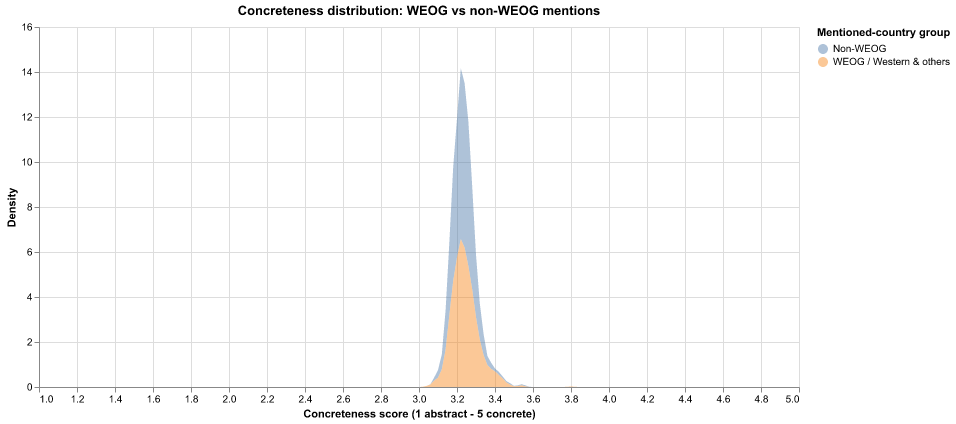

concreteness_by_year_region: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/concreteness_by_year_region.png


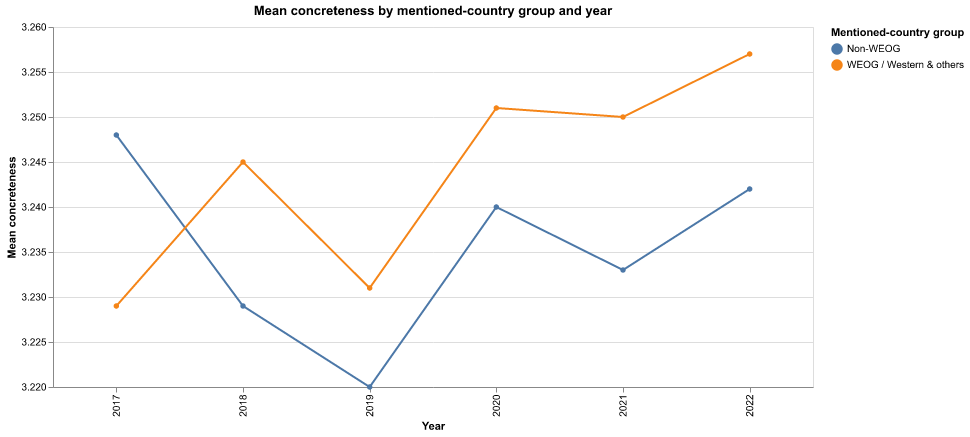

diffusion_top_targets: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/diffusion_top_targets.png


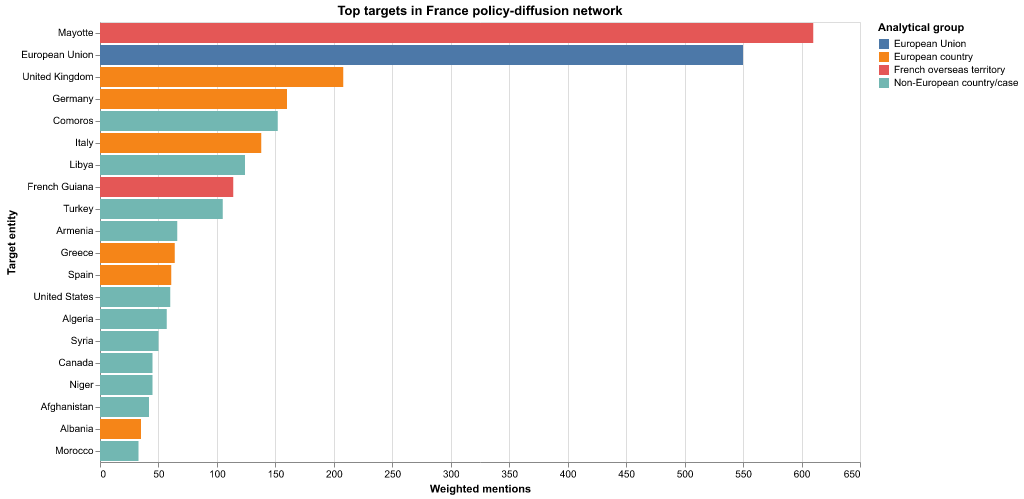

cohort_policy_heatmap: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/cohort_policy_heatmap.png


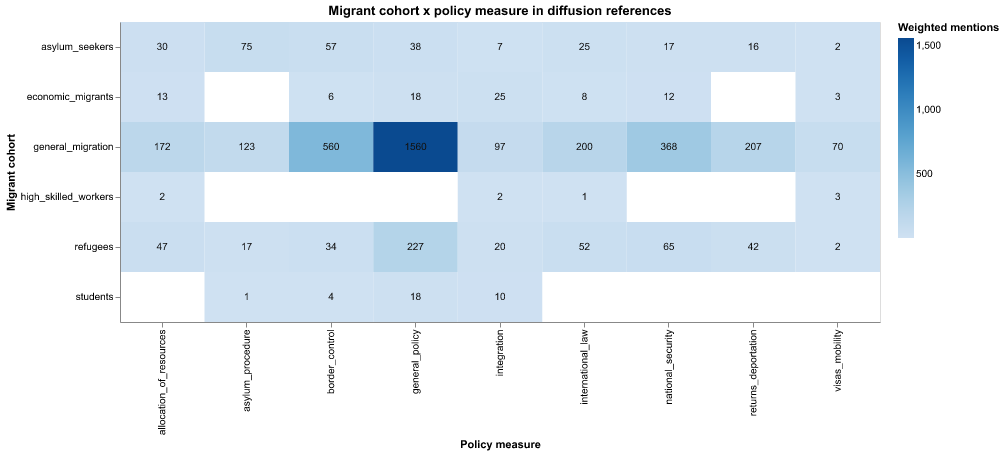

country_concreteness_bubble: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/country_concreteness_bubble.png


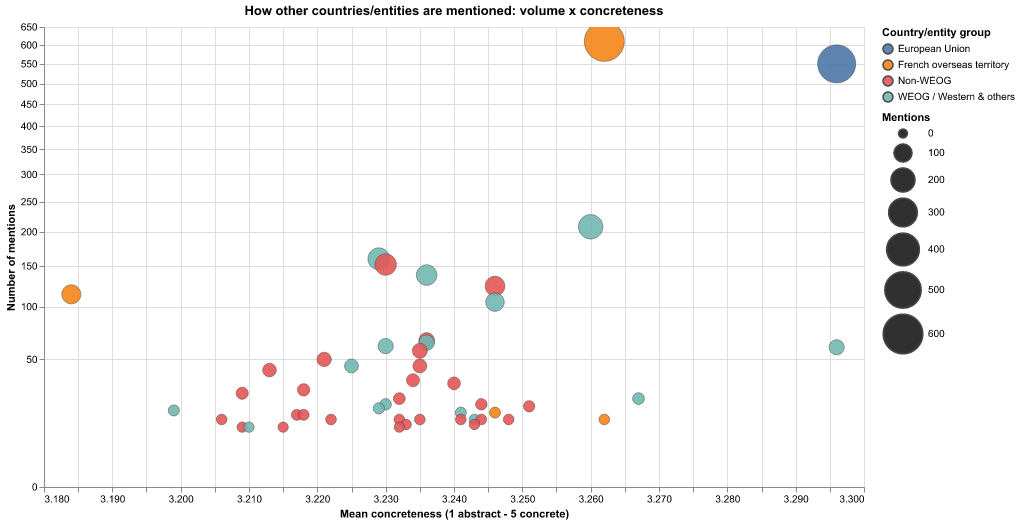

country_year_concreteness_heatmap: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/country_year_concreteness_heatmap.png


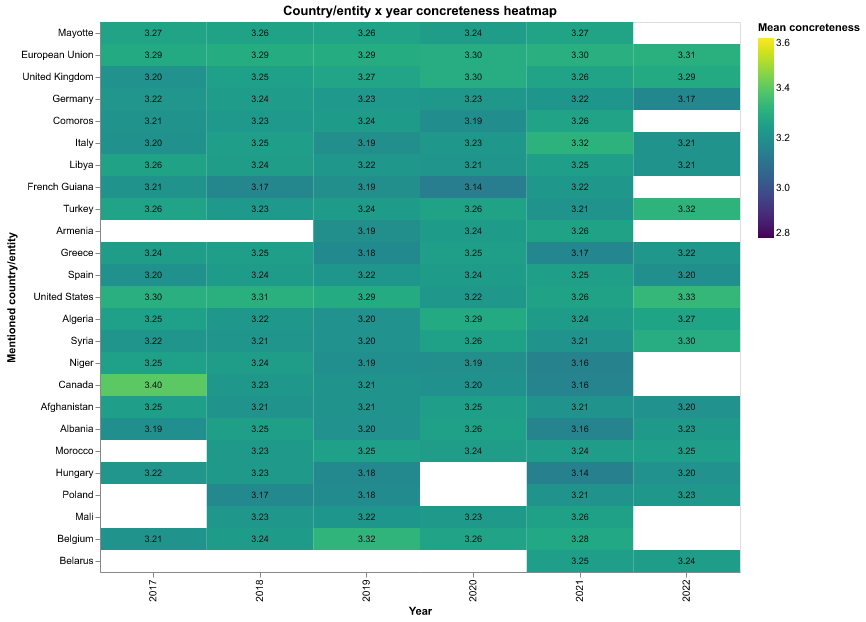

country_cohort_heatmap: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/country_cohort_heatmap.png


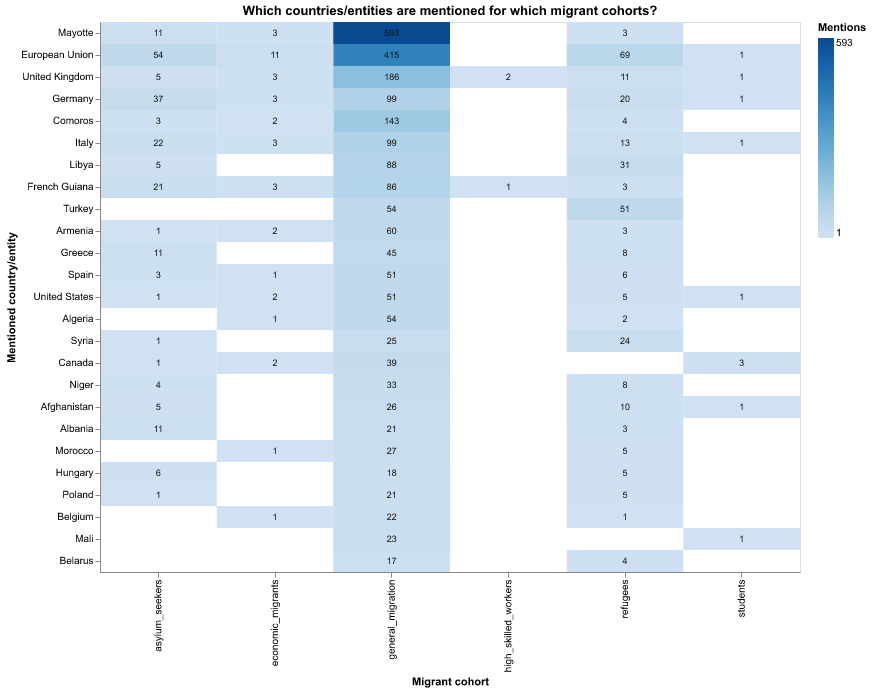

country_policy_heatmap: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/country_policy_heatmap.png


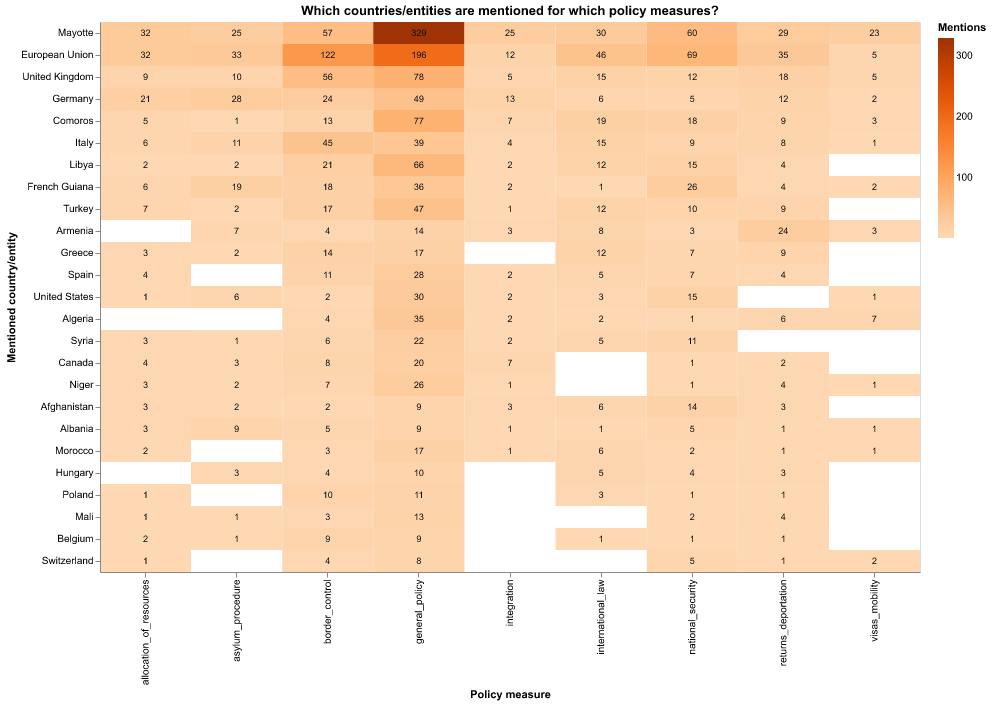

policy_agency_network: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_interactive_advanced/policy_agency_network.html
policy_agency_country_heatmap: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_interactive_advanced/policy_agency_country_heatmap.png


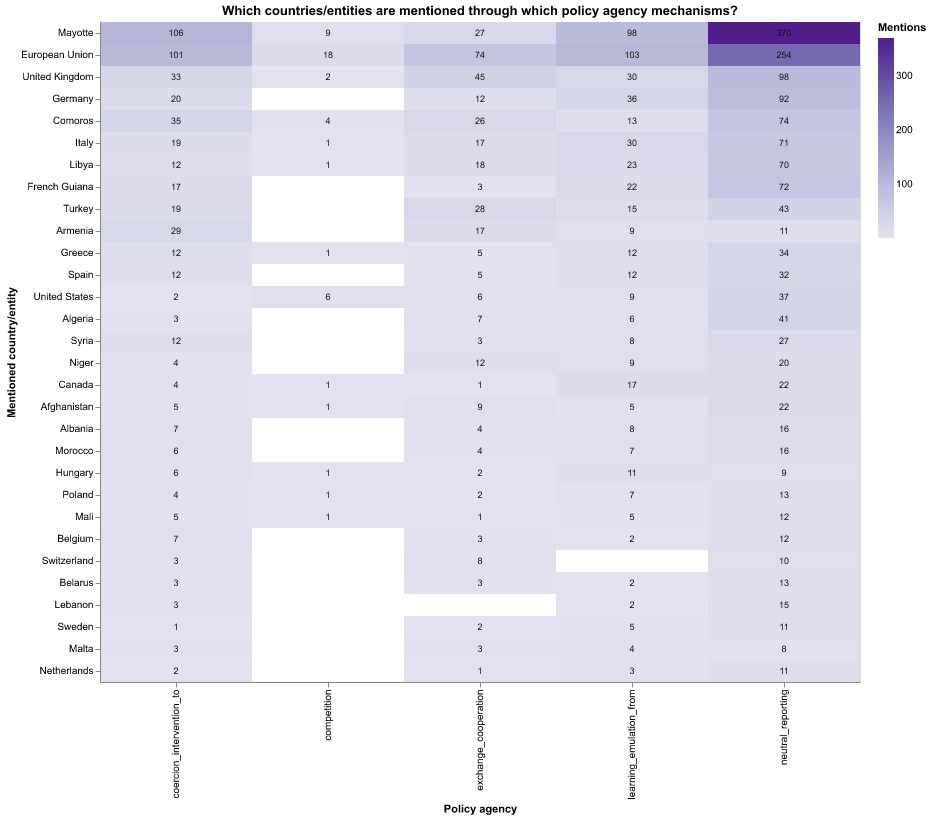

narrative_ternary: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_interactive_advanced/narrative_ternary.html
evidence_visibility_map: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_interactive_advanced/evidence_visibility_map.html
fact_density_timeline: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_interactive_advanced/fact_density_timeline.html

Interactive HTML files:
/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/cohort_policy_heatmap.html
/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/concreteness_by_year_region.html
/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration

In [16]:
# Explanation: Display saved static PNGs inline and print all interactive outputs.
all_figure_paths = {**figure_paths, **advanced_figure_paths}
for output_name, output_path in all_figure_paths.items():
    print(f"{output_name}: {output_path}")
    if str(output_path).endswith(".png"):
        display(Image(filename=str(output_path)))

print("\nInteractive HTML files:")
for folder in ["figures_altair_extended", "figures_interactive_advanced"]:
    for html_path in sorted((PROCESSED_DIR / folder).glob("*.html")):
        print(html_path)
